DISPARITY MAP COMPARISON ANALYSIS
Comparing ELAS, ADCE, and Ground Truth disparity maps

Loading disparity maps...
✓ Loaded Ground Truth (disp0): (1988, 2964)
✓ Loaded Ground Truth (disp00): (2000, 2964)
✓ Loaded ELAS left_original_sgm_fill: (2000, 2964)
✓ Loaded ELAS left_original_no_fill: (2000, 2964)
✓ Loaded ELAS left_camera_file_sgm_fill: (2000, 2964)
✓ Loaded ELAS left_camera_file_no_fill: (2000, 2964)
✓ Loaded ELAS right_original_sgm_fill: (2000, 2964)
✓ Loaded ELAS right_original_no_fill: (2000, 2964)
✓ Loaded ELAS right_camera_file_sgm_fill: (2000, 2964)
✓ Loaded ELAS right_camera_file_no_fill: (2000, 2964)
✓ Loaded ADCE original_fill_on: (569, 843)
✓ Loaded ADCE camera_file_fill_on: (569, 843)
✓ Loaded ADCE extended_range_Original_fill_on: (569, 843)
✓ Loaded ADCE extended_range_Balanced_fill_on: (569, 843)
✓ Loaded ADCE extended_range_LowTexture_fill_on: (569, 843)
✓ Loaded ADCE extended_range_Aggressive_fill_on: (569, 843)
✓ Loaded ADCE extended_range_QuickFix_fill_on: (569

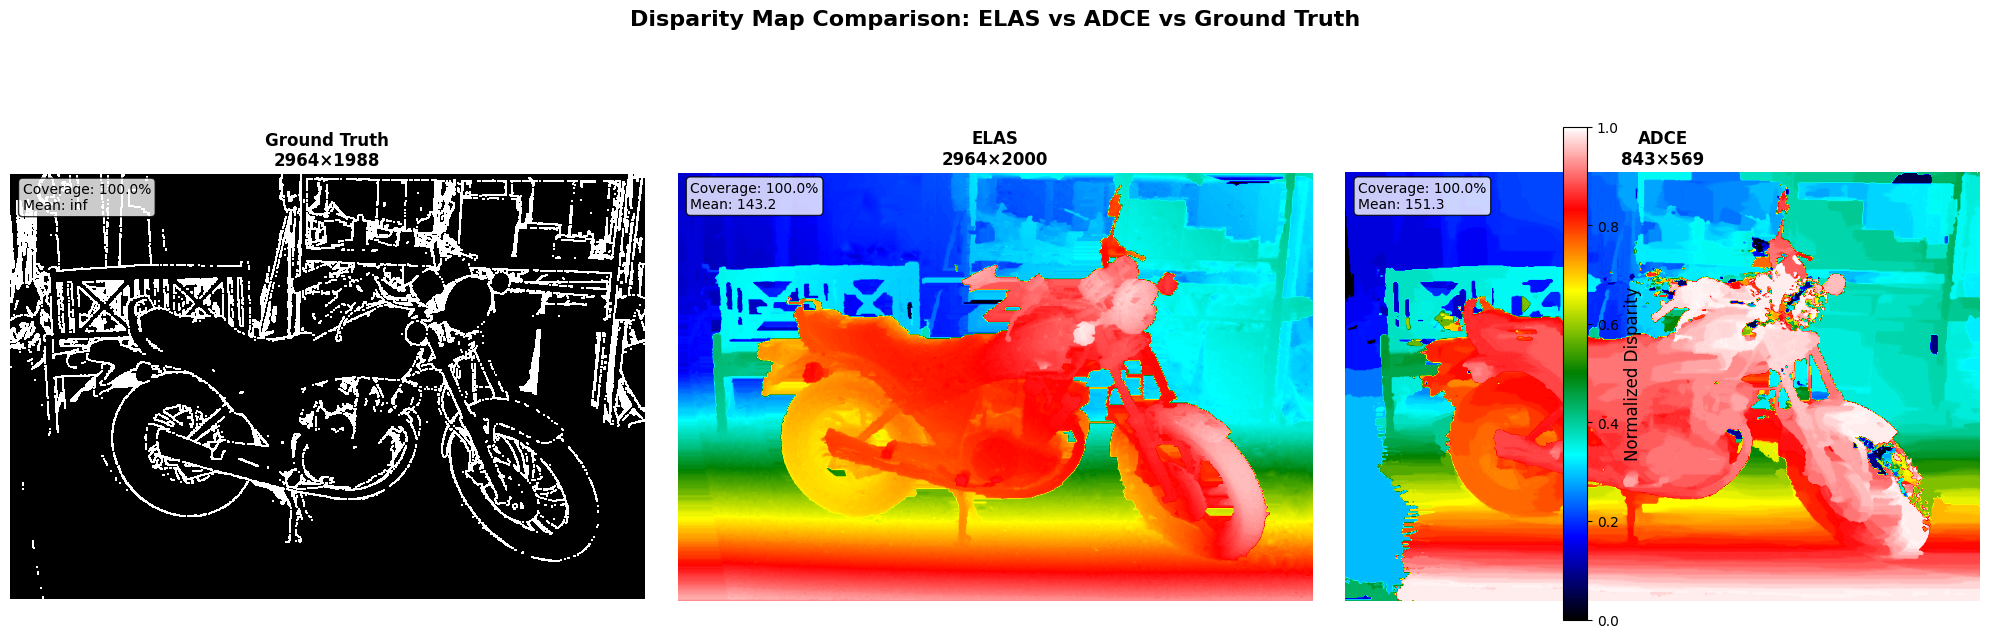

✓ Statistics plot saved to: disparity_statistics_comparison.png


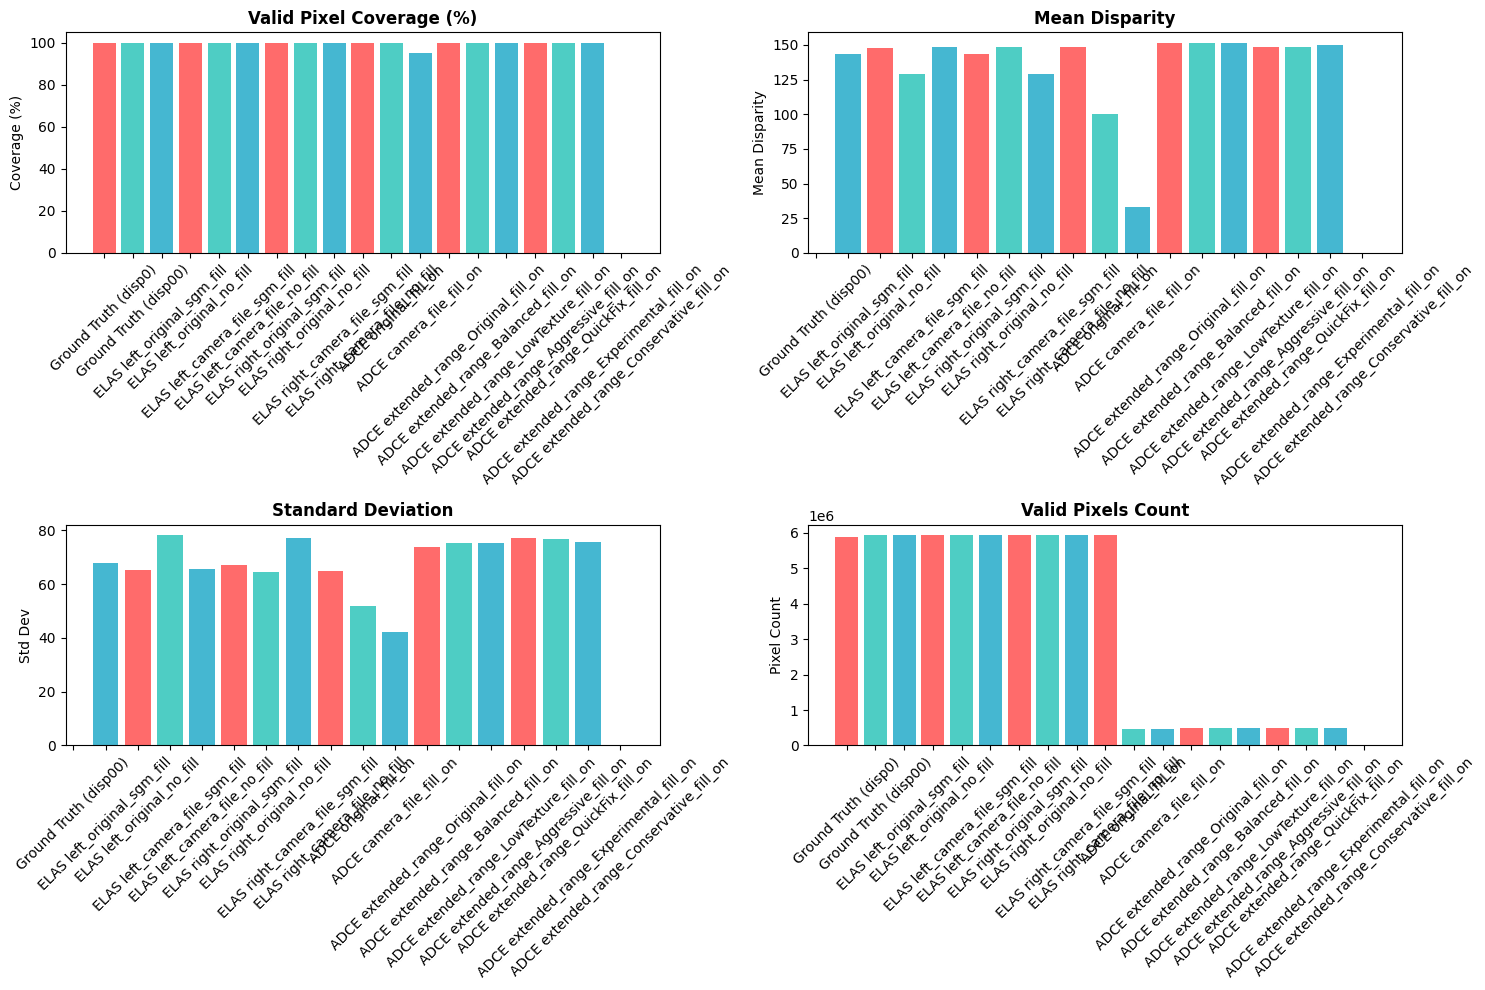


ANALYSIS COMPLETED
Generated files:
  - disparity_comparison_parallel.png
  - disparity_statistics_comparison.png


In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Disparity Map Comparison Analysis
================================

This notebook-style script compares different stereo matching algorithms:
- ELAS (Efficient Large-scale Stereo)
- SGM (Semi-Global Matching) 
- BM (Block Matching)
- ADCE (Adaptive Census)
- Ground Truth

Author: Generated for MysterroReconstr Project
Date: 2024
"""

import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualization
plt.style.use('default')
sns.set_palette("husl")

class DisparityAnalyzer:
    """Disparity map analysis and visualization class"""
    
    def __init__(self, data_dir="./"):
        self.data_dir = Path(data_dir)
        self.figsize = (20, 8)
        self.dpi = 100
        
    def read_pfm(self, filepath):
        """Read PFM file (Ground Truth disparity)"""
        with open(filepath, 'rb') as f:
            header = f.readline().decode('utf-8').strip()
            if header != 'Pf':
                raise ValueError('Not a PFM file')
            
            dims = f.readline().decode('utf-8').strip().split()
            width, height = int(dims[0]), int(dims[1])
            
            scale = float(f.readline().decode('utf-8').strip())
            data = np.frombuffer(f.read(), dtype=np.float32)
            data = data.reshape((height, width))
            
            if scale < 0:
                data = np.flipud(data)
            
            return data
    
    def read_png_disparity(self, filepath):
        """Read PNG disparity map"""
        img = cv2.imread(str(filepath), cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Warning: Could not read {filepath}")
            return None
        return img.astype(np.float32)
    
    def normalize_disparity(self, disparity, min_val=None, max_val=None):
        """Normalize disparity map for visualization"""
        if disparity is None:
            return None
            
        valid_mask = disparity > 0
        if not np.any(valid_mask):
            return np.zeros_like(disparity)
        
        if min_val is None:
            min_val = np.min(disparity[valid_mask])
        if max_val is None:
            max_val = np.max(disparity[valid_mask])
        
        normalized = np.zeros_like(disparity)
        normalized[valid_mask] = (disparity[valid_mask] - min_val) / (max_val - min_val)
        return normalized
    
    def create_disparity_colormap(self):
        """Create a custom colormap for disparity visualization"""
        colors = ['black', 'blue', 'cyan', 'green', 'yellow', 'red', 'white']
        n_bins = 256
        cmap = LinearSegmentedColormap.from_list('disparity_cmap', colors, N=n_bins)
        return cmap
    
    def load_all_disparity_maps(self):
        """Load all available disparity maps"""
        disparity_maps = {}
        
        # Ground Truth (PFM files)
        gt_files = {
            'Ground Truth (disp0)': 'disp0.pfm',
            'Ground Truth (disp00)': 'disp00.pfm'
        }
        
        for name, filename in gt_files.items():
            filepath = self.data_dir / filename
            if filepath.exists():
                try:
                    disparity_maps[name] = self.read_pfm(filepath)
                    print(f"✓ Loaded {name}: {disparity_maps[name].shape}")
                except Exception as e:
                    print(f"✗ Failed to load {name}: {e}")
        
        # ELAS Algorithm Results
        elas_patterns = [
            'disparity_ELAS_left_original_sgm_fill.png',
            'disparity_ELAS_left_original_no_fill.png',
            'disparity_ELAS_left_camera_file_sgm_fill.png',
            'disparity_ELAS_left_camera_file_no_fill.png',
            'disparity_ELAS_right_original_sgm_fill.png',
            'disparity_ELAS_right_original_no_fill.png',
            'disparity_ELAS_right_camera_file_sgm_fill.png',
            'disparity_ELAS_right_camera_file_no_fill.png'
        ]
        
        for pattern in elas_patterns:
            filepath = self.data_dir / pattern
            if filepath.exists():
                name = f"ELAS {pattern.replace('disparity_ELAS_', '').replace('.png', '')}"
                disparity_maps[name] = self.read_png_disparity(filepath)
                print(f"✓ Loaded {name}: {disparity_maps[name].shape}")
        
        # ADCE Algorithm Results
        adce_patterns = [
            'disparity_ADCE_original_fill_on.png',
            'disparity_ADCE_camera_file_fill_on.png',
            'disparity_ADCE_extended_range_Original_fill_on.png',
            'disparity_ADCE_extended_range_Balanced_fill_on.png',
            'disparity_ADCE_extended_range_LowTexture_fill_on.png',
            'disparity_ADCE_extended_range_HighQuality_fill_on.png',
            'disparity_ADCE_extended_range_Aggressive_fill_on.png',
            'disparity_ADCE_extended_range_QuickFix_fill_on.png',
            'disparity_ADCE_extended_range_Experimental_fill_on.png',
            'disparity_ADCE_extended_range_Conservative_fill_on.png'
        ]
        
        for pattern in adce_patterns:
            filepath = self.data_dir / pattern
            if filepath.exists():
                name = f"ADCE {pattern.replace('disparity_ADCE_', '').replace('.png', '')}"
                disparity_maps[name] = self.read_png_disparity(filepath)
                print(f"✓ Loaded {name}: {disparity_maps[name].shape}")
        
        return disparity_maps
    
    def select_representative_maps(self, disparity_maps):
        """Select representative maps for comparison"""
        selected_maps = {}
        
        # Ground Truth
        if 'Ground Truth (disp0)' in disparity_maps:
            selected_maps['Ground Truth'] = disparity_maps['Ground Truth (disp0)']
        
        # ELAS - select best performing variant
        elas_candidates = [k for k in disparity_maps.keys() if k.startswith('ELAS')]
        if elas_candidates:
            # Prefer left view with SGM fill
            preferred_elas = [k for k in elas_candidates if 'left' in k and 'sgm_fill' in k]
            if preferred_elas:
                selected_maps['ELAS'] = disparity_maps[preferred_elas[0]]
            else:
                selected_maps['ELAS'] = disparity_maps[elas_candidates[0]]
        
        # ADCE - select best performing variant
        adce_candidates = [k for k in disparity_maps.keys() if k.startswith('ADCE')]
        if adce_candidates:
            # Prefer extended range with balanced settings
            preferred_adce = [k for k in adce_candidates if 'extended_range' in k and 'Balanced' in k]
            if preferred_adce:
                selected_maps['ADCE'] = disparity_maps[preferred_adce[0]]
            else:
                selected_maps['ADCE'] = disparity_maps[adce_candidates[0]]
        
        return selected_maps
    
    def compute_statistics(self, disparity_maps):
        """Compute statistics for each disparity map"""
        stats = {}
        
        for name, disparity in disparity_maps.items():
            if disparity is None:
                continue
                
            valid_mask = disparity > 0
            if not np.any(valid_mask):
                stats[name] = {'valid_pixels': 0, 'total_pixels': disparity.size, 'coverage': 0.0, 'min': 0, 'max': 0, 'mean': 0, 'std': 0}
                continue
            
            valid_data = disparity[valid_mask]
            stats[name] = {
                'valid_pixels': np.sum(valid_mask),
                'total_pixels': disparity.size,
                'coverage': np.sum(valid_mask) / disparity.size * 100,
                'min': np.min(valid_data),
                'max': np.max(valid_data),
                'mean': np.mean(valid_data),
                'std': np.std(valid_data)
            }
        
        return stats
    
    def plot_disparity_comparison(self, disparity_maps, save_path=None):
        """Create parallel comparison plot of disparity maps"""
        
        # Select representative maps
        selected_maps = self.select_representative_maps(disparity_maps)
        
        if not selected_maps:
            print("No disparity maps found for comparison!")
            return
        
        # Create figure
        n_maps = len(selected_maps)
        fig, axes = plt.subplots(1, n_maps, figsize=self.figsize, dpi=self.dpi)
        
        if n_maps == 1:
            axes = [axes]
        
        # Create custom colormap
        cmap = self.create_disparity_colormap()
        
        # Plot each disparity map
        for i, (name, disparity) in enumerate(selected_maps.items()):
            if disparity is None:
                continue
                
            # Normalize for visualization
            normalized = self.normalize_disparity(disparity)
            
            # Plot
            im = axes[i].imshow(normalized, cmap=cmap, vmin=0, vmax=1)
            axes[i].set_title(f'{name}\n{disparity.shape[1]}×{disparity.shape[0]}', 
                            fontsize=12, fontweight='bold')
            axes[i].axis('off')
            
            # Add statistics text
            valid_mask = disparity > 0
            if np.any(valid_mask):
                coverage = np.sum(valid_mask) / disparity.size * 100
                mean_disp = np.mean(disparity[valid_mask])
                axes[i].text(0.02, 0.98, f'Coverage: {coverage:.1f}%\nMean: {mean_disp:.1f}', 
                           transform=axes[i].transAxes, fontsize=10,
                           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=axes, shrink=0.8, aspect=20)
        cbar.set_label('Normalized Disparity', fontsize=12)
        
        # Add main title
        fig.suptitle('Disparity Map Comparison: ELAS vs ADCE vs Ground Truth', 
                    fontsize=16, fontweight='bold', y=0.95)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"✓ Comparison plot saved to: {save_path}")
        
        plt.show()
        
        return fig
    
    def plot_statistics_comparison(self, disparity_maps, save_path=None):
        """Plot statistical comparison of disparity maps"""
        
        stats = self.compute_statistics(disparity_maps)
        
        if not stats:
            print("No statistics to plot!")
            return
        
        # Create comparison plots
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Extract data for plotting
        names = list(stats.keys())
        coverages = [stats[name]['coverage'] for name in names]
        means = [stats[name]['mean'] for name in names]
        stds = [stats[name]['std'] for name in names]
        valid_pixels = [stats[name]['valid_pixels'] for name in names]
        
        # Coverage comparison
        axes[0, 0].bar(names, coverages, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
        axes[0, 0].set_title('Valid Pixel Coverage (%)', fontweight='bold')
        axes[0, 0].set_ylabel('Coverage (%)')
        axes[0, 0].tick_params(axis='x', rotation=45)
        
        # Mean disparity comparison
        axes[0, 1].bar(names, means, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
        axes[0, 1].set_title('Mean Disparity', fontweight='bold')
        axes[0, 1].set_ylabel('Mean Disparity')
        axes[0, 1].tick_params(axis='x', rotation=45)
        
        # Standard deviation comparison
        axes[1, 0].bar(names, stds, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
        axes[1, 0].set_title('Standard Deviation', fontweight='bold')
        axes[1, 0].set_ylabel('Std Dev')
        axes[1, 0].tick_params(axis='x', rotation=45)
        
        # Valid pixels count
        axes[1, 1].bar(names, valid_pixels, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
        axes[1, 1].set_title('Valid Pixels Count', fontweight='bold')
        axes[1, 1].set_ylabel('Pixel Count')
        axes[1, 1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"✓ Statistics plot saved to: {save_path}")
        
        plt.show()
        
        return fig
    
    def print_detailed_statistics(self, disparity_maps):
        """Print detailed statistics for all disparity maps"""
        
        stats = self.compute_statistics(disparity_maps)
        
        print("\n" + "="*80)
        print("DETAILED DISPARITY MAP STATISTICS")
        print("="*80)
        
        for name, stat in stats.items():
            print(f"\n{name}:")
            print(f"  Shape: {disparity_maps[name].shape if disparity_maps[name] is not None else 'N/A'}")
            print(f"  Valid Pixels: {stat['valid_pixels']:,} / {stat['total_pixels']:,}")
            print(f"  Coverage: {stat['coverage']:.2f}%")
            print(f"  Range: [{stat['min']:.2f}, {stat['max']:.2f}]")
            print(f"  Mean: {stat['mean']:.2f}")
            print(f"  Std Dev: {stat['std']:.2f}")

def main():
    """Main analysis function"""
    
    print("="*80)
    print("DISPARITY MAP COMPARISON ANALYSIS")
    print("="*80)
    print("Comparing ELAS, ADCE, and Ground Truth disparity maps")
    print("="*80)
    
    # Initialize analyzer
    analyzer = DisparityAnalyzer()
    
    # Load all disparity maps
    print("\nLoading disparity maps...")
    disparity_maps = analyzer.load_all_disparity_maps()
    
    if not disparity_maps:
        print("No disparity maps found!")
        return
    
    print(f"\n✓ Loaded {len(disparity_maps)} disparity maps")
    
    # Print detailed statistics
    analyzer.print_detailed_statistics(disparity_maps)
    
    # Create comparison plots
    print("\nCreating comparison plots...")
    
    # Parallel comparison plot
    fig1 = analyzer.plot_disparity_comparison(
        disparity_maps, 
        save_path="disparity_comparison_parallel.png"
    )
    
    # Statistics comparison plot
    fig2 = analyzer.plot_statistics_comparison(
        disparity_maps, 
        save_path="disparity_statistics_comparison.png"
    )
    
    print("\n" + "="*80)
    print("ANALYSIS COMPLETED")
    print("="*80)
    print("Generated files:")
    print("  - disparity_comparison_parallel.png")
    print("  - disparity_statistics_comparison.png")
    print("="*80)

if __name__ == "__main__":
    main() 